In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
from scipy.io import loadmat

In [6]:
data = loadmat(r"C:\FINAL_SUMMER_PROJ\TPU_TEST_FILES\WIND_HIGH_RISE\T213_4_015_1.mat")


# 1. Flip the location data so it's a table
loc_matrix = data['Location_of_measured_points']
loc_df = pd.DataFrame(loc_matrix.T, columns=['X', 'Y', 'Point_No', 'Face_No'])

# 2. Extract the pressure time-series
if 'Wind_pressure_coefficients' in data:
    pressure_df = pd.DataFrame(data['Wind_pressure_coefficients'])
elif 'Pressure_coefficients' in data:
    pressure_df = pd.DataFrame(data['Pressure_coefficients'])
else:
    raise KeyError("Could not find any pressure coefficient matrices in this file!")
print(f"Total Taps: {len(loc_df)}")
print(f"Total Timesteps: {len(pressure_df)}")
print(loc_df.head())

Total Taps: 360
Total Timesteps: 32768
      X       Y  Point_No  Face_No
0  0.01  0.2875       1.0      1.0
1  0.03  0.2875       2.0      1.0
2  0.05  0.2875       3.0      1.0
3  0.07  0.2875       4.0      1.0
4  0.09  0.2875       5.0      1.0


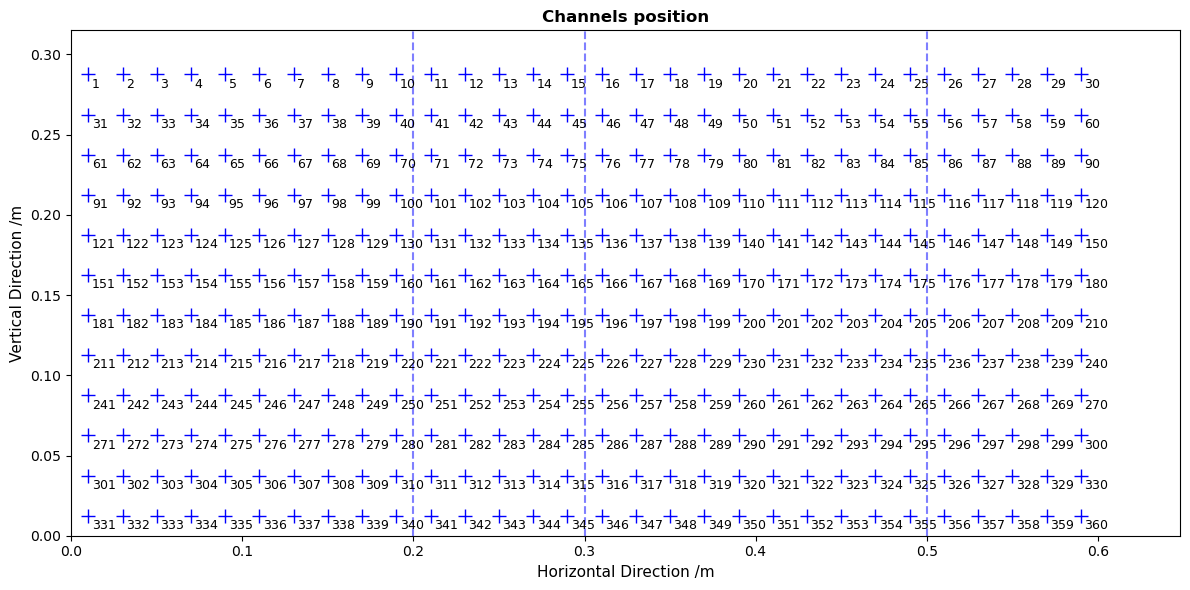

In [7]:
def get_channel_plot(loc_df, pressure_df):
        plt.figure(figsize=(12, 6))

        # 2. MATCH SIZES: Cap the location coordinates to the exact number of active channels
        total_active_channels = pressure_df.shape[1] # Number of columns in pressure matrix (200)
        active_loc_df = loc_df.head(total_active_channels).copy()

        # 3. Double-check column mapping if things look upside down:
        # If X and Y are swapped in the source matrix, flip them here:
        # x_coords = active_loc_df['Y'] 
        # y_coords = active_loc_df['X']
        x_coords = active_loc_df['X']
        y_coords = active_loc_df['Y']

        # Plot the active taps as blue crosses
        plt.scatter(x_coords, y_coords, marker='+', color='blue', s=100, linewidth=1)

        # 4. Iterate ONLY through the active capped dataframe
        for index, row in active_loc_df.iterrows():
            point_num = int(row['Point_No'])
            x_val = row['X']
            y_val = row['Y']
            
            # Offset the text slightly down and to the right so it doesn't overlap
            plt.text(x_val + 0.002, y_val - 0.002, str(point_num), 
                     color='black', fontsize=9, ha='left', va='top')

        # Add the vertical dashed lines separating sections

        # 1. Sort the taps horizontally from left to right
        sorted_loc = active_loc_df.sort_values(by='X')

        # 2. Track where the Face Number changes from one row to the next
        face_changes = sorted_loc['Face_No'].ne(sorted_loc['Face_No'].shift())
        
        # 3. Extract the exact X-coordinates where those shifts happen
        # We skip the very first point (index 0) because that's just the outer left wall
        boundary_xs = sorted_loc[face_changes]['X'].values[1:]

        # 4. Draw the dashed boundary lines exactly at the structural seam transitions
        for v_line in boundary_xs:

            snapped_line = round(v_line, 1)

            plt.axvline(x=snapped_line, color='blue', linestyle='--', alpha=0.5)

        # Lock the axes limits perfectly to the original geometry bounds
        x_min, x_max = x_coords.min(), x_coords.max()
        y_min, y_max = y_coords.min(), y_coords.max()
        
        x_buffer = (x_max - x_min) * 0.1 if x_max != x_min else 0.05
        y_buffer = (y_max - y_min) * 0.1 if y_max != y_min else 0.05

        plt.xlim(max(0, x_min - x_buffer), x_max + x_buffer)
        plt.ylim(max(0, y_min - y_buffer), y_max + y_buffer)

        plt.title("Channels position", fontweight='bold', fontsize=12)
        plt.xlabel("Horizontal Direction /m", fontsize=11)
        plt.ylabel("Vertical Direction /m", fontsize=11)

        plt.tight_layout()
        plt.show()

get_channel_plot(loc_df, pressure_df)

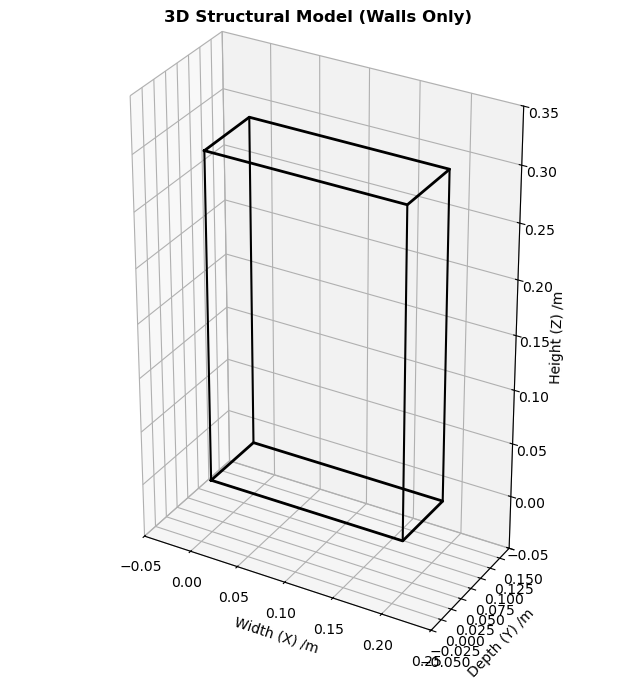

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_walls_only():
    # Clear any previous figures from memory
    plt.close('all')
    
    # Core dimensions from the 0.6m x 0.3m flat layout:
    # Face 1: 0.0 to 0.2 -> Width = 0.2
    # Face 2: 0.2 to 0.3 -> Depth = 0.1
    # Height: 0.0 to 0.3 -> Height = 0.3
    width = 0.2
    depth = 0.1
    height = 0.3

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 1. Define the 4 floor corners (X, Y)
    corners = [
        (0.0, 0.0),        # Front-Left
        (width, 0.0),      # Front-Right
        (width, depth),    # Back-Right
        (0.0, depth)       # Back-Left
    ]

    # 2. Draw the vertical corner edges
    for cx, cy in corners:
        ax.plot([cx, cx], [cy, cy], [0.0, height], color='black', linestyle='-', linewidth=1.5)

    # 3. Draw the horizontal rings (Bottom and Top perimeters)
    loop_x = [0.0, width, width, 0.0, 0.0]
    loop_y = [0.0, 0.0, depth, depth, 0.0]
    
    # Base Ring (Z = 0)
    ax.plot(loop_x, loop_y, [0.0, 0.0, 0.0, 0.0, 0.0], color='black', linewidth=2)
    # Roof Ring (Z = height)
    ax.plot(loop_x, loop_y, [height, height, height, height, height], color='black', linewidth=2)

    # 4. Set framing boundaries with a uniform buffer
    ax.set_xlim(-0.05, width + 0.05)
    ax.set_ylim(-0.05, depth + 0.05)
    ax.set_zlim(-0.05, height + 0.05)

    # Force true physical proportions to prevent distortion
    ax.set_box_aspect((width, depth, height))

    # Axis Labels
    ax.set_title("3D Structural Model (Walls Only)", fontweight='bold', fontsize=12)
    ax.set_xlabel("Width (X) /m", fontsize=10)
    ax.set_ylabel("Depth (Y) /m", fontsize=10)
    ax.set_zlabel("Height (Z) /m", fontsize=10)

    plt.show()

# Run the function
plot_walls_only()

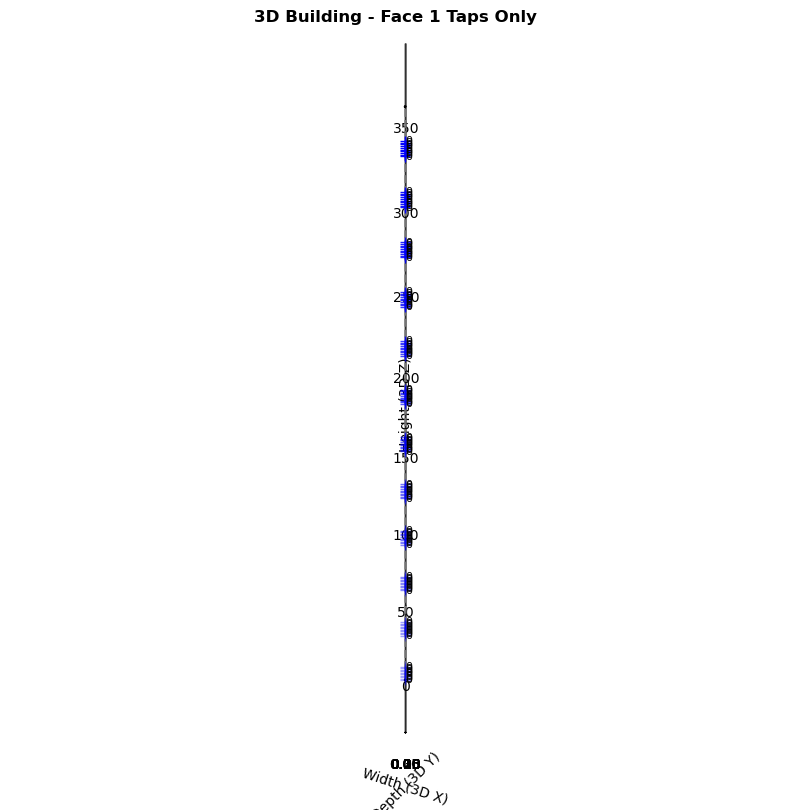

In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd

def get_channel_plot_3d(loc_df, pressure_df):
    # 1. Clear previous figure caches to prevent axis lock errors
    plt.close('all')
    
    # 2. Match size to active channels
    total_active_channels = pressure_df.shape[1]
    df = loc_df.head(total_active_channels).copy()

    # 3. Clean and convert data types safely by index position
    # Col 0: Point_No, Col 1: X, Col 2: Y, Col 3: Face_No (4th column)
    df.iloc[:, 0] = pd.to_numeric(df.iloc[:, 0], errors='coerce')
    df.iloc[:, 1] = pd.to_numeric(df.iloc[:, 1], errors='coerce')
    df.iloc[:, 2] = pd.to_numeric(df.iloc[:, 2], errors='coerce')
    df.iloc[:, 3] = pd.to_numeric(df.iloc[:, 3], errors='coerce')
    df = df.dropna(subset=[df.columns[0], df.columns[1], df.columns[2], df.columns[3]])

    # 4. Determine global height limits from the vertical Y column
    y_global_min = df.iloc[:, 2].min()
    y_global_max = df.iloc[:, 2].max()
    building_height = y_global_max - y_global_min

    # 5. Isolate only the first face ID found in the data
    unique_faces = sorted(df.iloc[:, 3].unique())
    face1_id = unique_faces[0]
    face1_df = df[df.iloc[:, 3] == face1_id]

    # 6. Determine building width from Face 1's horizontal X span
    x_f1_min = face1_df.iloc[:, 1].min()
    x_f1_max = face1_df.iloc[:, 1].max()
    building_width = x_f1_max - x_f1_min

    # Determine building depth from Face 2's span (if it exists in the data)
    if len(unique_faces) > 1:
        face2_df = df[df.iloc[:, 3] == unique_faces[1]]
        building_depth = face2_df.iloc[:, 1].max() - face2_df.iloc[:, 1].min()
    else:
        building_depth = building_width * 0.5  # Fallback thickness

    # 7. Map Face 1 coordinates cleanly relative to a (0,0,0) origin
    # 3D Width (X) = Local horizontal position on Face 1
    x_3d = (face1_df.iloc[:, 1] - x_f1_min).tolist()
    # 3D Depth (Y) = 0 (pinned flat against the front wall surface)
    y_3d = [0.0] * len(face1_df)
    # 3D Height (Z) = Direct vertical map from your dataframe's Y column
    z_3d = (face1_df.iloc[:, 2] - y_global_min).tolist()

    pts = face1_df.iloc[:, 0].astype(int).tolist()

    # 8. Generate 3D Canvas
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 9. Draw the wireframe box matching the actual calculated building size
    corners = [(0.0, 0.0), (building_width, 0.0), (building_width, building_depth), (0.0, building_depth)]
    for cx, cy in corners:
        ax.plot([cx, cx], [cy, cy], [0.0, building_height], color='gray', linestyle='--', alpha=0.4)
        
    for z_level in [0.0, building_height]:
        ax.plot([0.0, building_width, building_width, 0.0, 0.0], 
                [0.0, 0.0, building_depth, building_depth, 0.0], 
                [z_level, z_level, z_level, z_level, z_level], color='black', linewidth=1.5)

    # 10. Superimpose the Face 1 Pressure Taps (Blue Crosses)
    ax.scatter(x_3d, y_3d, z_3d, marker='+', color='blue', s=60, linewidths=1)

    # 11. Add text labels next to each tap
    for i in range(len(x_3d)):
        ax.text(x_3d[i] + (building_width * 0.01), y_3d[i], z_3d[i], str(pts[i]), 
                color='black', fontsize=8, va='center')

    # 12. Enforce clean limits and proportional 3D boundaries
    ax.set_xlim(-building_width * 0.1, building_width * 1.1)
    ax.set_ylim(-building_depth * 0.1, building_depth * 1.1)
    ax.set_zlim(-building_height * 0.1, building_height * 1.1)
    ax.set_box_aspect((building_width, building_depth, building_height))

    ax.set_title(f"3D Building - Face {int(face1_id)} Taps Only", fontweight='bold', fontsize=12)
    ax.set_xlabel("Width (3D X)", fontsize=10)
    ax.set_ylabel("Depth (3D Y)", fontsize=10)
    ax.set_zlabel("Height (3D Z)", fontsize=10)

    plt.show()

get_channel_plot_3d(loc_df, pressure_df)